# Prozesszeitreihenanalyse mit dem TCLab

Dieses Notebook überträgt die vorherige synthetische Zeitreihenanalyse auf das Temperature Control Lab (TCLab).

Das Notebook kann wahlweise mit echter TCLab-Hardware oder mit der TCLab-Simulation betrieben werden.

Im Mittelpunkt stehen:

- Erzeugung eines Stufenprofils der Heizleistung
- Aufzeichnung von `Q1`, `Q2`, `T1` und `T2`
- Zeitindex, Abtastzeit, Rolling Mean und Lag-Features
- ACF und PACF für Temperaturzeitreihen
- Cross-Correlation zwischen Heizleistung und Temperatur
- Cross-Correlation zwischen zwei Temperaturmessgrößen
- STL-Zerlegung zur explorativen Trennung von Verlauf, Zyklus und Residuum

Die Simulation ist standardmäßig aktiviert. Für echte Hardware muss nur ein Konfigurationsschalter geändert werden.


## Lernziel und Lerninhalte

Nach der Bearbeitung können Sie:

- ein Stufenprofil für eine reale oder simulierte Prozessmessung erzeugen,
- die Messdaten des TCLab als Zeitreihe strukturieren,
- Autokorrelation und partielle Autokorrelation an realitätsnahen Temperaturdaten interpretieren,
- Cross-Correlation zur Untersuchung zeitlicher Verzögerungen nutzen,
- erklären, warum eine CCF bei trägen Prozessen nicht zwingend die reine Totzeit liefert,
- Messgrößen `T1` und `T2` als gekoppelte Prozesszeitreihen vergleichen,
- die Grenzen von Zeitreihenzerlegung und Korrelationsanalyse bei kurzen Laborversuchen einschätzen.


## Quellen und technische Orientierung

Das Notebook orientiert sich an den offiziellen APMonitor- und TCLab-Materialien:

- APMonitor / TCLab: Step Tests zur Erzeugung dynamischer Daten
- APMonitor: TCLab-Simulation und vereinfachtes dynamisches Temperaturmodell
- `tclab`-Python-Paket: `TCLab`, `clock`, `TCLabModel`, `setup`
- TCLab-Dokumentation: Simulation mit `setup(connected=False, speedup=...)`
- J. C. Kantor: Nutzung von `clock()` für zeitlich getaktete Experimente

Die didaktische Auswertung orientiert sich am vorherigen Notebook zu Prozesszeitreihen, wird hier aber auf echte bzw. simulierte Messdaten übertragen.


## 1. Installation und Setup

Für das Notebook werden benötigt:

- `numpy`
- `pandas`
- `matplotlib`
- `statsmodels`
- `tclab`

Installation bei Bedarf:

```bash
pip install tclab statsmodels
```

oder in einer Conda-Umgebung:

```bash
conda install -c conda-forge statsmodels
pip install tclab
```

Hinweis für echte Hardware:

- TCLab über USB anschließen.
- Netzteil des TCLab anschließen.
- Falls nötig, Arduino-Firmware nach TCLab-Anleitung installieren.
- Während des Experiments die Temperatur beobachten.


In [5]:
import time
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from IPython.display import clear_output, display

from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
from statsmodels.tsa.seasonal import STL

plt.rcParams["figure.figsize"] = (12, 4)
plt.rcParams["axes.grid"] = True

rng = np.random.default_rng(42)

## 2. Konfiguration

Die wichtigste Einstellung ist `USE_HARDWARE`.

- `USE_HARDWARE = False`: TCLab-Simulation
- `USE_HARDWARE = True`: echte TCLab-Hardware

Das Stufenprofil ist absichtlich deutlich ausgeprägt. Die Plateaus sind lang genug, damit die thermische Trägheit des TCLab sichtbar wird.

Für die Simulation wird `SIM_SPEEDUP` verwendet. Dadurch läuft das Experiment deutlich schneller als in Echtzeit.


In [7]:
# ------------------------------------------------------------
# Betriebsart
# ------------------------------------------------------------
USE_HARDWARE = True      # False = Simulation, True = echte TCLab-Hardware
SIM_SPEEDUP = 50          # nur für Simulation relevant

# ------------------------------------------------------------
# Messdauer und Abtastung
# ------------------------------------------------------------
SAMPLE_TIME_S = 2         # typische Abtastzeit für TCLab-Versuche

PROFILE_CYCLE_S = 600     # Länge eines Stufenzyklus in Sekunden
N_CYCLES = 2              # zwei Zyklen unterstützen die spätere Zerlegung
T_FINAL_S = PROFILE_CYCLE_S * N_CYCLES
STL_PERIOD_S = PROFILE_CYCLE_S

# ------------------------------------------------------------
# Glättung und Lag-Beispiele
# ------------------------------------------------------------
# Für TCLab-Daten sind 30 s oft noch recht kurz. 90 bis 120 s sind meist ruhiger.
ROLLING_WINDOW_S = 120
LAG_EXAMPLE_S = 60

# ------------------------------------------------------------
# Sicherheit und Komfort
# ------------------------------------------------------------
MAX_TEMPERATURE_C = 70.0  # Sicherheitsgrenze für echte Hardware
SHOW_LIVE_PLOT = True
LIVE_PLOT_EVERY_N = 20    # Live-Plot nur alle n Messpunkte aktualisieren

# ------------------------------------------------------------
# Speichern und Laden
# ------------------------------------------------------------
DATA_DIR = Path("data_tclab")
DATA_DIR.mkdir(exist_ok=True)

CSV_PATH = DATA_DIR / "tclab_stufentest_zeitreihenanalyse.csv"

RUN_NEW_EXPERIMENT = True
LOAD_EXISTING_CSV = False

expected_runtime_s = T_FINAL_S if USE_HARDWARE else T_FINAL_S / SIM_SPEEDUP

print(f"Betriebsart: {'Hardware' if USE_HARDWARE else 'Simulation'}")
print(f"Messdauer Prozesszeit: {T_FINAL_S / 60:.1f} min")
print(f"Abtastzeit: {SAMPLE_TIME_S} s")
print(f"Profilzyklus für STL: {STL_PERIOD_S / 60:.1f} min")
print(f"Rolling-Fenster für EDA: {ROLLING_WINDOW_S} s")
print(f"Lag-Beispiel: {LAG_EXAMPLE_S} s")
print(f"Erwartete reale Laufzeit: ca. {expected_runtime_s / 60:.1f} min")
print(f"CSV-Zielpfad: {CSV_PATH}")

Betriebsart: Hardware
Messdauer Prozesszeit: 20.0 min
Abtastzeit: 2 s
Profilzyklus für STL: 10.0 min
Rolling-Fenster für EDA: 120 s
Lag-Beispiel: 60 s
Erwartete reale Laufzeit: ca. 20.0 min
CSV-Zielpfad: data_tclab\tclab_stufentest_zeitreihenanalyse.csv


## 3. Stufenprofil der Heizleistung

Die Heizleistung `Q1` wird als wiederholtes Stufenprofil vorgegeben.

Das Profil enthält deutliche Sprünge:

- Start bei 0 %
- Sprung auf 70 %
- Absenkung auf 25 %
- Sprung auf 85 %
- Abkühlen bei 0 %

`Q2` bleibt standardmäßig ausgeschaltet. Dadurch kann untersucht werden, wie stark `T2` durch thermische Kopplung auf `Q1` reagiert.

Falls ein deutlicheres Signal in `T2` benötigt wird, kann später gezielt auch `Q2` angeregt werden. Für diese Grundlagenübung bleibt `Q2` aber zunächst aus.


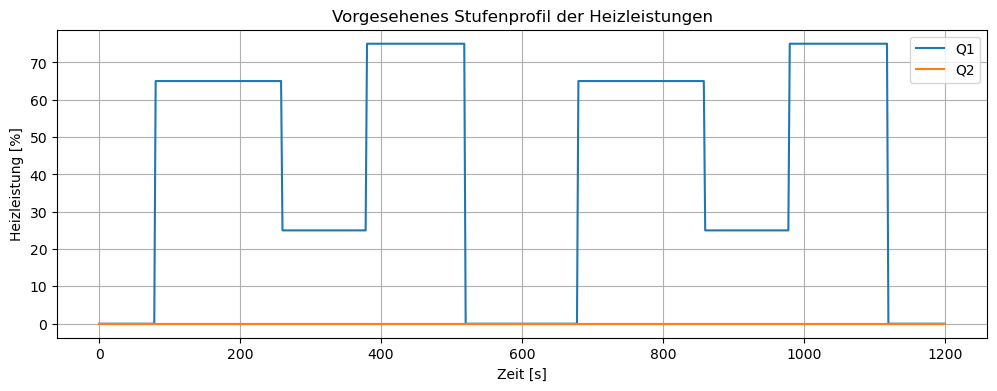

,time_s,Q1,Q2
0,0,0.0,0.0
1,2,0.0,0.0
2,4,0.0,0.0
3,6,0.0,0.0
4,8,0.0,0.0


In [9]:
def heater_profile_q1(t_s):
    """Stufenprofil für Heizer 1.

    Das Profil wird über mehrere Zyklen wiederholt.
    t_s ist die Prozesszeit in Sekunden.

    Das Profil ist absichtlich deutlich, aber nicht zu aggressiv gewählt.
    Dadurch entstehen sichtbare Temperatursprünge, ohne dass die Simulation
    oder Hardware zu früh an die Temperaturgrenze kommt.
    """
    t_cycle = t_s % PROFILE_CYCLE_S

    if t_cycle < 80:
        return 0.0
    elif t_cycle < 260:
        return 65.0
    elif t_cycle < 380:
        return 25.0
    elif t_cycle < 520:
        return 75.0
    else:
        return 0.0


def heater_profile_q2(t_s):
    """Stufenprofil für Heizer 2.

    Standardmäßig bleibt Q2 ausgeschaltet.
    """
    return 0.0


# Vorschau des Stufenprofils
time_preview = np.arange(0, T_FINAL_S + SAMPLE_TIME_S, SAMPLE_TIME_S)
q1_preview = np.array([heater_profile_q1(t) for t in time_preview])
q2_preview = np.array([heater_profile_q2(t) for t in time_preview])

profile_df = pd.DataFrame({
    "time_s": time_preview,
    "Q1": q1_preview,
    "Q2": q2_preview,
})

ax = profile_df.plot(x="time_s", y=["Q1", "Q2"])
ax.set_title("Vorgesehenes Stufenprofil der Heizleistungen")
ax.set_xlabel("Zeit [s]")
ax.set_ylabel("Heizleistung [%]")
plt.show()

profile_df.head()

## 4. Hilfsfunktionen für die Auswertung

Für die Cross-Correlation wird wieder eine eigene kleine Funktion verwendet.

Interpretation in diesem Notebook:

- positiver Lag: `signal_b` folgt `signal_a`
- negativer Lag: `signal_b` liegt vor `signal_a`

Die Funktion nutzt `numpy`-Arrays, damit die Werte positionsweise verglichen werden. Das ist wichtig, weil `pandas.Series` bei Rechenoperationen nach Indexlabels ausrichtet.


In [11]:
def lagged_cross_correlation(signal_a, signal_b, max_lag):
    """Berechnet eine normalisierte Cross-Correlation für positive und negative Lags.

    Positive Lags bedeuten:
    signal_b folgt signal_a um die angegebene Anzahl an Samples.
    """
    a = np.asarray(signal_a, dtype=float)
    b = np.asarray(signal_b, dtype=float)

    lags = np.arange(-max_lag, max_lag + 1)
    values = []

    for lag in lags:
        if lag < 0:
            a_aligned = a[-lag:]
            b_aligned = b[:lag]
        elif lag > 0:
            a_aligned = a[:-lag]
            b_aligned = b[lag:]
        else:
            a_aligned = a
            b_aligned = b

        valid = np.isfinite(a_aligned) & np.isfinite(b_aligned)
        a_aligned = a_aligned[valid]
        b_aligned = b_aligned[valid]

        if len(a_aligned) < 3:
            values.append(np.nan)
            continue

        a_centered = a_aligned - np.mean(a_aligned)
        b_centered = b_aligned - np.mean(b_aligned)

        a_std = np.std(a_centered)
        b_std = np.std(b_centered)

        if a_std == 0 or b_std == 0:
            values.append(np.nan)
        else:
            values.append(np.mean((a_centered / a_std) * (b_centered / b_std)))

    return pd.DataFrame({"lag": lags, "ccf": values})


def plot_ccf(signal_a, signal_b, max_lag, sample_time_s, title, expected_lag=None):
    """Berechnet und plottet die Cross-Correlation zweier Signale."""
    ccf_df = lagged_cross_correlation(signal_a, signal_b, max_lag=max_lag)
    best_row = ccf_df.loc[ccf_df["ccf"].idxmax()]
    best_lag = int(best_row["lag"])
    best_delay_s = best_lag * sample_time_s

    plt.figure(figsize=(12, 4))
    plt.stem(ccf_df["lag"], ccf_df["ccf"])
    plt.axvline(best_lag, linestyle="--", label=f"Maximum: Lag {best_lag}")
    if expected_lag is not None:
        plt.axvline(expected_lag, linestyle=":", label=f"Referenz: Lag {expected_lag}")
    plt.title(title)
    plt.xlabel("Lag [Samples]")
    plt.ylabel("Cross-Correlation")
    plt.legend()
    plt.show()

    print(f"Maximum bei Lag = {best_lag} Samples")
    print(f"Entspricht ca. {best_delay_s:.1f} s")

    return ccf_df, best_lag, best_delay_s


def add_timedelta_index(df, time_col="time_s"):
    """Erzeugt eine Kopie mit TimedeltaIndex für Resampling."""
    out = df.copy()
    out.index = pd.to_timedelta(out[time_col], unit="s")
    out.index.name = "elapsed_time"
    return out


def create_regular_analysis_grid(df_raw, sample_time_s):
    """Erzeugt ein äquidistantes Zeitraster für die Zeitreihenanalyse.

    Warum ist das wichtig?
    ACF, PACF, CCF und Lag-Features setzen praktisch ein gleichmäßiges
    Zeitraster voraus. Bei Hardwaremessungen und teilweise bei Simulationen
    können einzelne Zeitpunkte leicht unregelmäßig sein.

    Temperaturwerte werden linear interpoliert.
    Heizleistungen werden als Stufensignale per Zero-Order-Hold übernommen.
    """
    raw = df_raw.copy()
    raw = raw.sort_values("time_s").drop_duplicates("time_s").reset_index(drop=True)

    t_start = 0.0
    t_end = float(raw["time_s"].max())
    time_grid = np.arange(t_start, t_end + 0.5 * sample_time_s, sample_time_s)

    regular = pd.DataFrame({"time_s": time_grid})
    raw_sorted = raw.sort_values("time_s")

    # Stellgrößen als Stufensignale: letzten bekannten Wert übernehmen
    for col in ["Q1", "Q2"]:
        if col in raw_sorted.columns:
            matched = pd.merge_asof(
                regular[["time_s"]],
                raw_sorted[["time_s", col]],
                on="time_s",
                direction="backward",
            )
            regular[col] = matched[col].ffill().fillna(0.0)

    # Temperaturen als kontinuierlich gedachte Messgrößen: linear interpolieren
    for col in ["T1", "T2"]:
        if col in raw_sorted.columns:
            regular[col] = np.interp(
                time_grid,
                raw_sorted["time_s"].to_numpy(dtype=float),
                raw_sorted[col].to_numpy(dtype=float),
            )

    return regular


def time_shifted_feature(df, value_col, delay_s, time_col="time_s"):
    """Erzeugt ein zeitbasiertes Lag-Feature über Interpolation.

    Ergebnis am Zeitpunkt t:
    value_col(t - delay_s)

    Positive delay_s bedeuten also: Wert aus der Vergangenheit.
    Im Gegensatz zu df.shift(n) ist diese Funktion zeitbasiert und nicht
    nur zeilenbasiert.
    """
    time_values = df[time_col].to_numpy(dtype=float)
    values = df[value_col].to_numpy(dtype=float)

    return np.interp(
        time_values - delay_s,
        time_values,
        values,
        left=np.nan,
        right=np.nan,
    )

## 5. TCLab-Experiment ausführen oder Daten laden

Diese Zelle führt den eigentlichen Stufentest aus.

Ablauf:

1. Verbindung zu Hardware oder Simulation herstellen.
2. In jedem Zeitschritt `Q1` und `Q2` setzen.
3. Temperaturen `T1` und `T2` lesen.
4. Daten in einer Tabelle speichern.
5. Am Ende beide Heizer sicher auf 0 % setzen.

Bei echter Hardware läuft das Experiment in Echtzeit. Bei Simulation wird `SIM_SPEEDUP` verwendet.


t = 1200 s von 1200 s
Q1 = 0.0 %, Q2 = 0.0 %, T1 = 47.77 °C, T2 = 36.69 °C


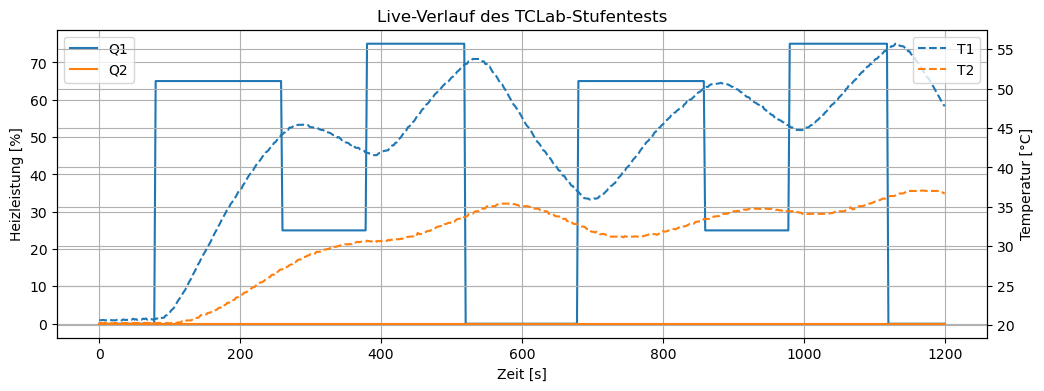

TCLab disconnected successfully.
Daten gespeichert unter: data_tclab\tclab_stufentest_zeitreihenanalyse.csv


,time_s,wall_time_s,Q1,Q2,T1,T2
0,0.00,4.514656,0.0,0.0,20.608,20.254
1,2.00,6.482645,0.0,0.0,20.608,20.254
2,4.00,8.486357,0.0,0.0,20.608,20.222
3,6.00,10.477542,0.0,0.0,20.641,20.222
4,8.01,12.495886,0.0,0.0,20.576,20.254


In [13]:
if LOAD_EXISTING_CSV and CSV_PATH.exists():
    df = pd.read_csv(CSV_PATH)
    print(f"Daten geladen aus: {CSV_PATH}")

elif RUN_NEW_EXPERIMENT:
    try:
        import tclab
    except ImportError as exc:
        raise ImportError(
            "Das Paket 'tclab' ist nicht installiert. Bitte installieren mit: pip install tclab"
        ) from exc

    if USE_HARDWARE:
        LabClass = tclab.TCLab
    else:
        LabClass = tclab.setup(connected=False, speedup=SIM_SPEEDUP)

    rows = []
    start_wall_time = time.time()

    with LabClass() as lab:
        try:
            for i, t in enumerate(tclab.clock(T_FINAL_S, SAMPLE_TIME_S)):
                q1 = heater_profile_q1(t)
                q2 = heater_profile_q2(t)

                lab.Q1(q1)
                lab.Q2(q2)

                t1 = float(lab.T1)
                t2 = float(lab.T2)

                rows.append({
                    "time_s": float(t),
                    "wall_time_s": time.time() - start_wall_time,
                    "Q1": q1,
                    "Q2": q2,
                    "T1": t1,
                    "T2": t2,
                })

                # Sicherheitsabbruch für Hardware
                if USE_HARDWARE and max(t1, t2) >= MAX_TEMPERATURE_C:
                    print(f"Sicherheitsabbruch: Temperaturgrenze {MAX_TEMPERATURE_C} °C erreicht.")
                    break

                # gelegentlicher Live-Plot
                if SHOW_LIVE_PLOT and (i % LIVE_PLOT_EVERY_N == 0 or i == 0):
                    live_df = pd.DataFrame(rows)
                    clear_output(wait=True)
                    print(f"t = {t:.0f} s von {T_FINAL_S:.0f} s")
                    print(f"Q1 = {q1:.1f} %, Q2 = {q2:.1f} %, T1 = {t1:.2f} °C, T2 = {t2:.2f} °C")

                    fig, ax1 = plt.subplots(figsize=(12, 4))
                    ax1.plot(live_df["time_s"], live_df["Q1"], label="Q1")
                    ax1.plot(live_df["time_s"], live_df["Q2"], label="Q2")
                    ax1.set_xlabel("Zeit [s]")
                    ax1.set_ylabel("Heizleistung [%]")
                    ax1.legend(loc="upper left")

                    ax2 = ax1.twinx()
                    ax2.plot(live_df["time_s"], live_df["T1"], label="T1", linestyle="--")
                    ax2.plot(live_df["time_s"], live_df["T2"], label="T2", linestyle="--")
                    ax2.set_ylabel("Temperatur [°C]")
                    ax2.legend(loc="upper right")

                    plt.title("Live-Verlauf des TCLab-Stufentests")
                    plt.show()

        finally:
            # Heizer immer ausschalten
            lab.Q1(0)
            lab.Q2(0)

    df = pd.DataFrame(rows)
    df.to_csv(CSV_PATH, index=False)
    print(f"Daten gespeichert unter: {CSV_PATH}")

else:
    raise RuntimeError("Bitte RUN_NEW_EXPERIMENT=True setzen oder LOAD_EXISTING_CSV=True verwenden.")

df.head()

## 6. Messdaten prüfen und Analyse-Zeitgitter erzeugen

Zuerst wird geprüft, ob die Messung ausreichend lang ist und ob die Temperaturverläufe plausibel sind.

Für echte Hardware können kleine Zeitabweichungen entstehen. Deshalb wird die Messung anschließend auf ein reguläres Zeitraster gebracht.

Das ist wichtig für:

- Lag-Features,
- ACF und PACF,
- Cross-Correlation,
- STL-Zerlegung.

Die Rohdaten bleiben in `df_raw` erhalten. Die weitere Analyse verwendet `df` auf einem äquidistanten Raster.


In [15]:
print("Datenumfang der Rohdaten:")
print(df.shape)
print()

print("Erste Zeilen der Rohdaten:")
display(df.head())

print("Letzte Zeilen der Rohdaten:")
display(df.tail())

print("Kurzstatistik der Rohdaten:")
display(df[["Q1", "Q2", "T1", "T2"]].describe())

dt = df["time_s"].diff().dropna()
print("Abtastzeit-Kontrolle Rohdaten:")
print(f"Median dt: {dt.median():.3f} s")
print(f"Minimum dt: {dt.min():.3f} s")
print(f"Maximum dt: {dt.max():.3f} s")
print()

# Rohdaten sichern und reguläres Analyse-Zeitgitter erzeugen
df_raw = df.copy()
df = create_regular_analysis_grid(df_raw, sample_time_s=SAMPLE_TIME_S)

print("Datenumfang nach Regularisierung:")
print(df.shape)
print()

dt_regular = df["time_s"].diff().dropna()
print("Abtastzeit-Kontrolle Analyse-Zeitgitter:")
print(f"Median dt: {dt_regular.median():.3f} s")
print(f"Minimum dt: {dt_regular.min():.3f} s")
print(f"Maximum dt: {dt_regular.max():.3f} s")

df_ts = add_timedelta_index(df, time_col="time_s")

Datenumfang der Rohdaten:
(601, 6)

Erste Zeilen der Rohdaten:


,time_s,wall_time_s,Q1,Q2,T1,T2
0,0.00,4.514656,0.0,0.0,20.608,20.254
1,2.00,6.482645,0.0,0.0,20.608,20.254
2,4.00,8.486357,0.0,0.0,20.608,20.222
3,6.00,10.477542,0.0,0.0,20.641,20.222
4,8.01,12.495886,0.0,0.0,20.576,20.254


Letzte Zeilen der Rohdaten:


,time_s,wall_time_s,Q1,Q2,T1,T2
596,1192.01,1196.493567,0.0,0.0,48.936,37.012
597,1194.01,1198.492018,0.0,0.0,48.613,36.979
598,1196.01,1200.488133,0.0,0.0,48.291,36.883
599,1198.00,1202.482985,0.0,0.0,48.001,36.754
600,1200.01,1204.492332,0.0,0.0,47.775,36.689


Kurzstatistik der Rohdaten:


,Q1,Q2,T1,T2
count,601.000000,601.0,601.000000,601.000000
mean,41.930116,0.0,42.694507,30.712597
std,30.723527,0.0,9.391932,5.139715
min,0.000000,0.0,20.576000,20.157000
25%,0.000000,0.0,39.235000,28.955000
50%,65.000000,0.0,45.036000,32.178000
75%,65.000000,0.0,49.387000,34.466000
max,75.000000,0.0,55.703000,37.076000


Abtastzeit-Kontrolle Rohdaten:
Median dt: 2.000 s
Minimum dt: 1.980 s
Maximum dt: 2.010 s

Datenumfang nach Regularisierung:
(601, 5)

Abtastzeit-Kontrolle Analyse-Zeitgitter:
Median dt: 2.000 s
Minimum dt: 2.000 s
Maximum dt: 2.000 s


## 7. Erste Visualisierung

`Q1` ist die aktive Anregung. `T1` sollte deutlich auf `Q1` reagieren.

`T2` reagiert typischerweise schwächer und verzögert, wenn `Q2` ausgeschaltet bleibt. Dadurch entsteht ein realistisches Beispiel für gekoppelte Prozessmessgrößen.

Die Heizleistungen und Temperaturen werden auf zwei y-Achsen dargestellt. Für die Temperaturkurven wird bewusst ein normaler Linienplot verwendet. Stufige Effekte entstehen hier vor allem durch diskrete Abtastung, kurze Glättungsfenster oder spätere Lag-Darstellungen.


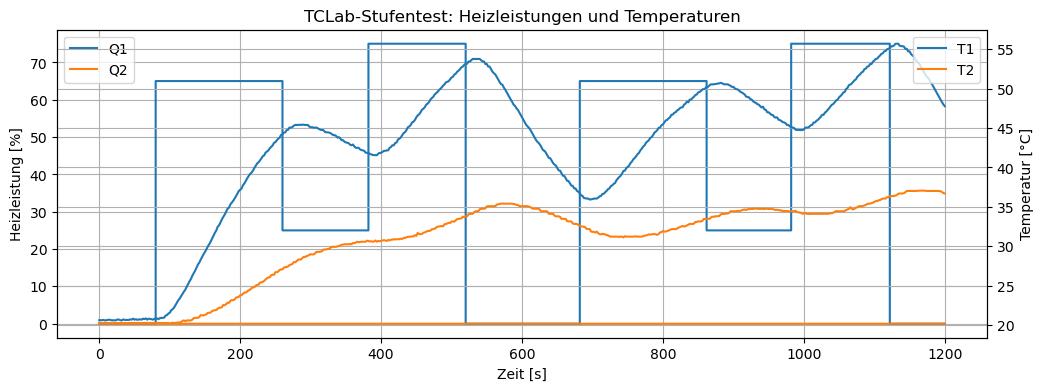

In [17]:
fig, ax1 = plt.subplots(figsize=(12, 4))

ax1.step(df["time_s"], df["Q1"], label="Q1", where="post")
ax1.step(df["time_s"], df["Q2"], label="Q2", where="post")
ax1.set_xlabel("Zeit [s]")
ax1.set_ylabel("Heizleistung [%]")
ax1.legend(loc="upper left")

ax2 = ax1.twinx()
ax2.plot(df["time_s"], df["T1"], label="T1", linestyle="-", linewidth=1.5)
ax2.plot(df["time_s"], df["T2"], label="T2", linestyle="-", linewidth=1.5)
ax2.set_ylabel("Temperatur [°C]")
ax2.legend(loc="upper right")

plt.title("TCLab-Stufentest: Heizleistungen und Temperaturen")
plt.show()

## 8. Resampling und gleitende Mittelwerte

Die weitere Analyse verwendet das reguläre Zeitraster aus Abschnitt 6.

Wichtiger Hinweis zur Glättung:

Ein normaler gleitender Mittelwert ist in `pandas` standardmäßig rückblickend. Er verwendet also nur aktuelle und vergangene Werte. Das ist für Online-Anwendungen korrekt, erzeugt in der Visualisierung aber einen sichtbaren Nachlauf.

Für die explorative Analyse wird deshalb hier zusätzlich ein zentrierter gleitender Mittelwert verwendet. Dieser ist besser für die Darstellung geeignet, darf aber nicht als kausales Online-Feature für spätere Modelle verwendet werden.

Außerdem wird das Glättungsfenster mit `ROLLING_WINDOW_S` bewusst größer gewählt. Bei zu kurzen Fenstern, z. B. 30 s bei 10 s Abtastzeit, entsteht nur ein Mittelwert über drei Punkte. Das kann optisch stufig wirken.


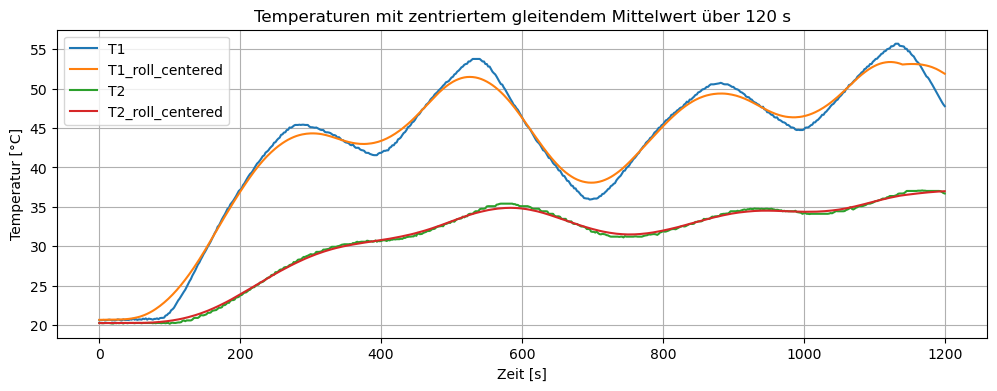

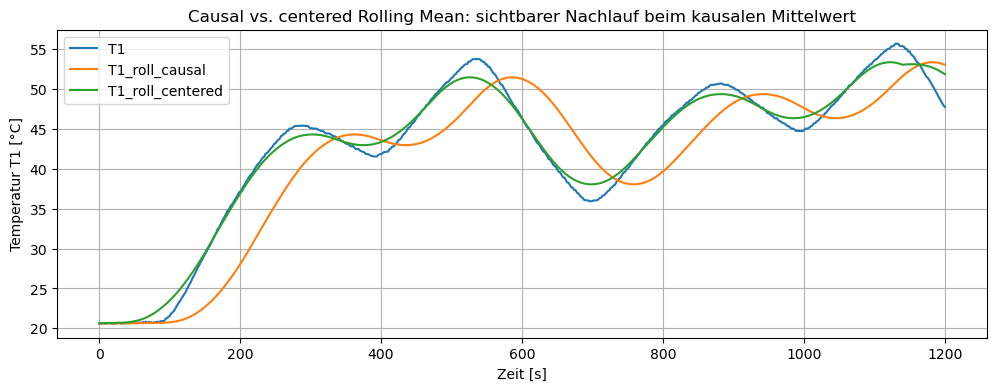

,Q1,Q2,T1,T2
elapsed_time,,,,
0 days 00:00:00,0.0,0.0,20.608265,20.241168
0 days 00:00:10,0.0,0.0,20.627833,20.234665
0 days 00:00:20,0.0,0.0,20.633935,20.228200
0 days 00:00:30,0.0,0.0,20.634232,20.240968
0 days 00:00:40,0.0,0.0,20.692303,20.247600


In [19]:
# TimedeltaIndex für zeitbasierte Operationen
df_ts = add_timedelta_index(df, time_col="time_s")

# Resampling auf 10-Sekunden-Mittelwerte
# Das dient nur der tabellarischen Kontrolle und wird nicht als Hauptsignal geplottet.
df_10s = df_ts[["Q1", "Q2", "T1", "T2"]].resample("10s").mean()

# Zeitbasierte gleitende Mittelwerte
rolling_rule = f"{ROLLING_WINDOW_S}s"

# Causal / rückblickend: gut für Online-Features, aber mit sichtbarem Nachlauf
df_ts["T1_roll_causal"] = df_ts["T1"].rolling(
    rolling_rule,
    min_periods=1,
    center=False
).mean()
df_ts["T2_roll_causal"] = df_ts["T2"].rolling(
    rolling_rule,
    min_periods=1,
    center=False
).mean()

# Centered / zentriert: gut für explorative Visualisierung, aber nicht kausal
df_ts["T1_roll_centered"] = df_ts["T1"].rolling(
    rolling_rule,
    min_periods=1,
    center=True
).mean()
df_ts["T2_roll_centered"] = df_ts["T2"].rolling(
    rolling_rule,
    min_periods=1,
    center=True
).mean()

# Zurück in den normalen DataFrame übernehmen
for col in ["T1_roll_causal", "T2_roll_causal", "T1_roll_centered", "T2_roll_centered"]:
    df[col] = df_ts[col].to_numpy()

# Vergleich: rohes Signal und zentrierte Glättung
ax = df.plot(x="time_s", y=["T1", "T1_roll_centered", "T2", "T2_roll_centered"])
ax.set_title(f"Temperaturen mit zentriertem gleitendem Mittelwert über {ROLLING_WINDOW_S} s")
ax.set_xlabel("Zeit [s]")
ax.set_ylabel("Temperatur [°C]")
plt.show()

# Demonstration des Offset-Effekts beim kausalen Rolling Mean
ax = df.plot(x="time_s", y=["T1", "T1_roll_causal", "T1_roll_centered"])
ax.set_title("Causal vs. centered Rolling Mean: sichtbarer Nachlauf beim kausalen Mittelwert")
ax.set_xlabel("Zeit [s]")
ax.set_ylabel("Temperatur T1 [°C]")
plt.show()

display(df_10s.head())

## 9. Lag-Features und sichtbarer Zeitversatz

Lag-Features enthalten vergangene Werte eines Signals.

Bei Prozesszeitreihen sind sie wichtig, weil der aktuelle Zustand häufig von früheren Temperaturen und früheren Stellgrößen abhängt.

Beispiele:

- Heizleistung vor 60 s
- Temperatur `T1` vor 60 s
- Temperatur `T2` vor 60 s

Wichtiger Hinweis:

Wenn ein Lag-Feature gegen die aktuelle Zeit geplottet wird, sieht es absichtlich zeitlich versetzt aus. Das ist kein Fehler, sondern die Bedeutung des Features: Zum Zeitpunkt $t$ enthält das Lag-Feature den Wert $T1(t - 60\,s)$.

In dieser Version werden Lag-Features zeitbasiert mit Interpolation berechnet. Das ist robuster als ein rein zeilenbasiertes `df.shift(n)`, wenn die Rohmessung kleine Unregelmäßigkeiten im Zeitraster enthält.


In [21]:
lag_label_s = int(round(LAG_EXAMPLE_S))

q1_past_col = f"Q1_past_{lag_label_s}s"
t1_past_col = f"T1_past_{lag_label_s}s"
t2_past_col = f"T2_past_{lag_label_s}s"

df[q1_past_col] = time_shifted_feature(df, "Q1", delay_s=LAG_EXAMPLE_S)
df[t1_past_col] = time_shifted_feature(df, "T1", delay_s=LAG_EXAMPLE_S)
df[t2_past_col] = time_shifted_feature(df, "T2", delay_s=LAG_EXAMPLE_S)

df["T1_past_120s"] = time_shifted_feature(df, "T1", delay_s=120)

preview_rows = int(round(140 / SAMPLE_TIME_S))
df[
    [
        "time_s",
        "Q1",
        q1_past_col,
        "T1",
        t1_past_col,
        "T1_past_120s",
        "T2",
        t2_past_col,
    ]
].head(preview_rows)

,time_s,Q1,Q1_past_60s,T1,T1_past_60s,T1_past_120s,T2,T2_past_60s
0,0.0,0.0,NaN,20.608000,NaN,NaN,20.254000,NaN
1,2.0,0.0,NaN,20.608000,NaN,NaN,20.254000,NaN
2,4.0,0.0,NaN,20.608000,NaN,NaN,20.222000,NaN
3,6.0,0.0,NaN,20.641000,NaN,NaN,20.222000,NaN
4,8.0,0.0,NaN,20.576323,NaN,NaN,20.253841,NaN
...,...,...,...,...,...,...,...,...
65,130.0,65.0,0.0,25.827550,20.801355,20.607840,20.576000,20.25400
66,132.0,65.0,0.0,26.245905,20.770160,20.641000,20.672515,20.25400
67,134.0,65.0,0.0,26.570000,20.737165,20.672841,20.866000,20.25400
68,136.0,65.0,0.0,26.893000,20.673320,20.641160,20.898000,20.22216


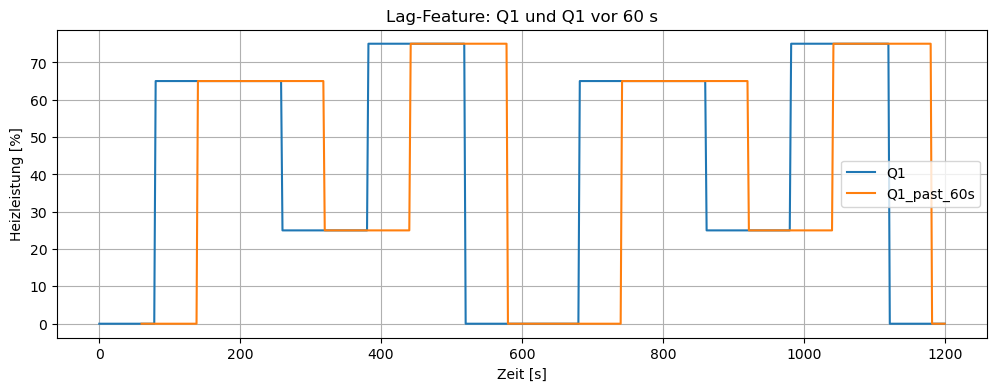

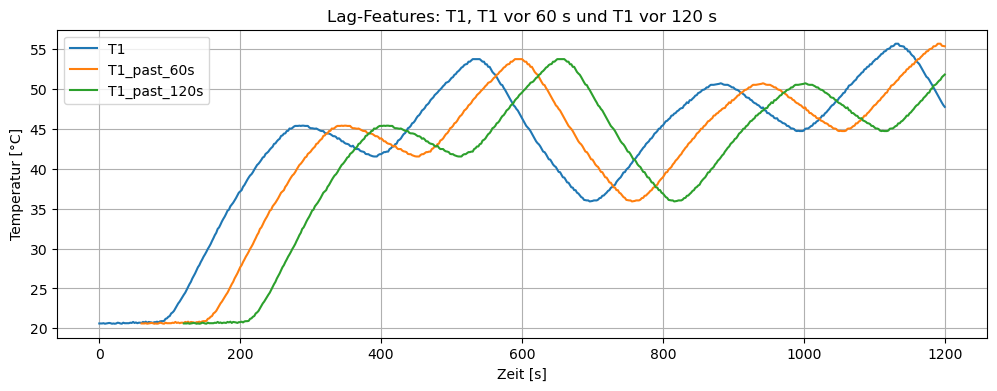

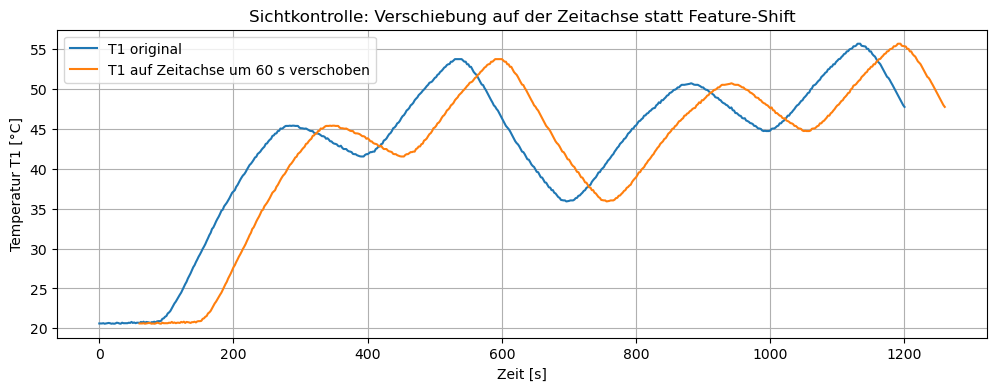

In [22]:
ax = df.plot(x="time_s", y=["Q1", q1_past_col])
ax.set_title(f"Lag-Feature: Q1 und Q1 vor {lag_label_s} s")
ax.set_xlabel("Zeit [s]")
ax.set_ylabel("Heizleistung [%]")
plt.show()

ax = df.plot(x="time_s", y=["T1", t1_past_col, "T1_past_120s"])
ax.set_title(f"Lag-Features: T1, T1 vor {lag_label_s} s und T1 vor 120 s")
ax.set_xlabel("Zeit [s]")
ax.set_ylabel("Temperatur [°C]")
plt.show()

# Alternative Sichtkontrolle:
# Hier wird nicht der Wert als Feature verzögert, sondern die Zeitachse verschoben.
# Dadurch erkennt man, dass das Lag-Feature nur eine zeitlich verschobene Version von T1 ist.
plt.figure(figsize=(12, 4))
plt.plot(df["time_s"], df["T1"], label="T1 original")
plt.plot(df["time_s"] + LAG_EXAMPLE_S, df["T1"], label=f"T1 auf Zeitachse um {lag_label_s} s verschoben")
plt.title("Sichtkontrolle: Verschiebung auf der Zeitachse statt Feature-Shift")
plt.xlabel("Zeit [s]")
plt.ylabel("Temperatur T1 [°C]")
plt.legend()
plt.grid(True)
plt.show()

## 10. Autokorrelation von `T1`

Die Autokorrelation zeigt, wie stark `T1` mit den eigenen vergangenen Werten zusammenhängt.

Bei einem thermisch trägen System ist eine hohe Autokorrelation typisch. Temperaturwerte ändern sich nicht sprunghaft, sondern entwickeln sich über viele Zeitschritte.


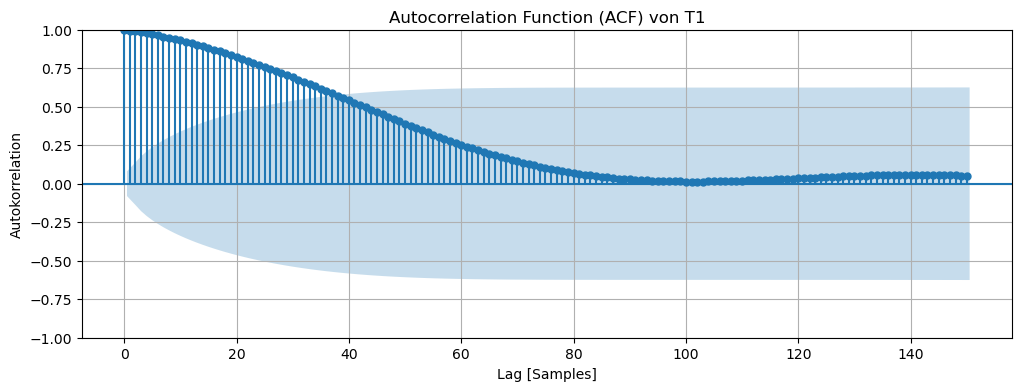

In [24]:
max_lag_acf = int(300 / SAMPLE_TIME_S)

fig = plot_acf(df["T1"], lags=max_lag_acf)
plt.title("Autocorrelation Function (ACF) von T1")
plt.xlabel("Lag [Samples]")
plt.ylabel("Autokorrelation")
plt.show()

## 11. Partielle Autokorrelation von `T1`

Die partielle Autokorrelation betrachtet direkte Zusammenhänge mit einzelnen Lags, nachdem kürzere Lags berücksichtigt wurden.

Bei realen Prozessdaten ist die PACF oft schwieriger zu interpretieren als die ACF. Sie ist trotzdem hilfreich, um zu zeigen, dass Zeitreihenpunkte nicht unabhängig sind.


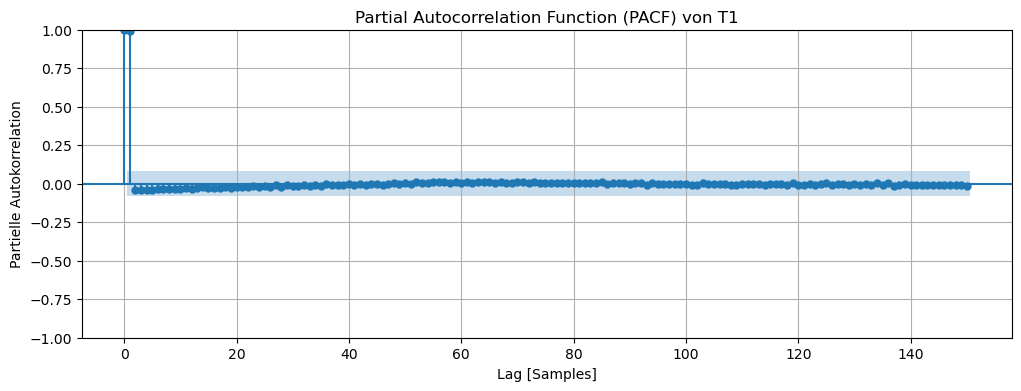

In [26]:
fig = plot_pacf(df["T1"], lags=max_lag_acf, method="ywm")
plt.title("Partial Autocorrelation Function (PACF) von T1")
plt.xlabel("Lag [Samples]")
plt.ylabel("Partielle Autokorrelation")
plt.show()

## 12. Cross-Correlation zwischen `Q1` und `T1`

Jetzt wird untersucht, wie stark die Temperatur `T1` zeitlich verzögert auf die Heizleistung `Q1` reagiert.

Wichtig: Die CCF liefert hier nicht automatisch die reine Totzeit. Das TCLab ist ein träges thermisches System. Das Maximum beschreibt daher eher eine effektive Signalverzögerung aus Totzeit, Trägheit und Stufenprofil.

Für die Lehre ist genau dieser Punkt wichtig: Bei realen Prozesszeitreihen muss die CCF technisch interpretiert werden.


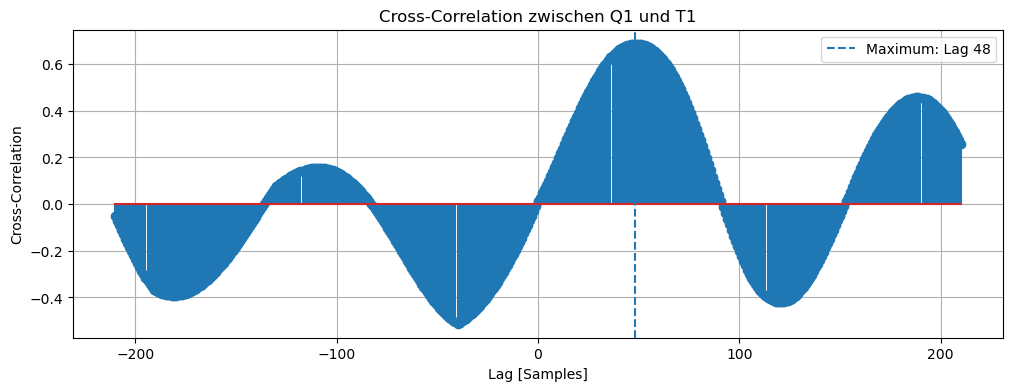

Maximum bei Lag = 48 Samples
Entspricht ca. 96.0 s

Interpretation:
Ein positiver Lag bedeutet: T1 folgt Q1.
Bei einem trägen thermischen Prozess kann das Maximum deutlich später liegen als eine reine Transporttotzeit.


In [28]:
max_lag_ccf = int(420 / SAMPLE_TIME_S)

ccf_q1_t1, best_lag_q1_t1, best_delay_q1_t1_s = plot_ccf(
    signal_a=df["Q1"],
    signal_b=df["T1"],
    max_lag=max_lag_ccf,
    sample_time_s=SAMPLE_TIME_S,
    title="Cross-Correlation zwischen Q1 und T1"
)

print()
print("Interpretation:")
print("Ein positiver Lag bedeutet: T1 folgt Q1.")
print("Bei einem trägen thermischen Prozess kann das Maximum deutlich später liegen als eine reine Transporttotzeit.")

## 13. Cross-Correlation zwischen `T1` und `T2`

`T1` und `T2` sind zwei Temperaturmessgrößen im TCLab.

Wenn `Q2` ausgeschaltet bleibt, kann `T2` trotzdem durch thermische Kopplung auf Änderungen an `Q1` reagieren. Diese Reaktion ist meist schwächer und verzögerter als bei `T1`.

Die CCF zwischen `T1` und `T2` untersucht, ob `T2` dem Verlauf von `T1` zeitlich folgt.


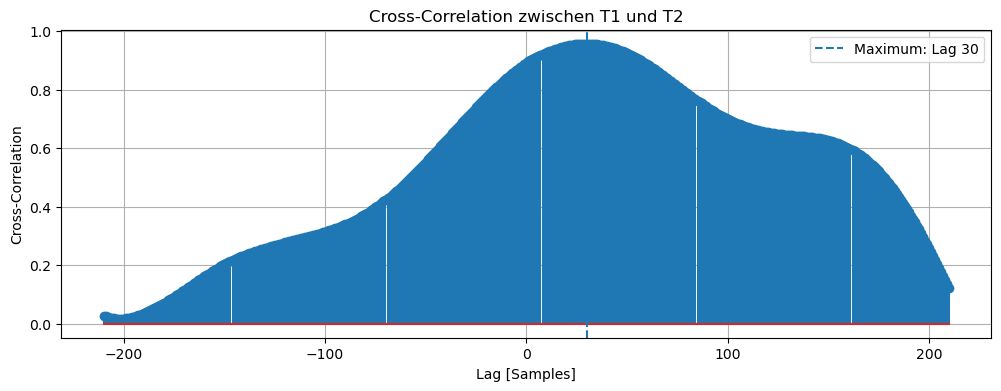

Maximum bei Lag = 30 Samples
Entspricht ca. 60.0 s

Interpretation:
Ein positiver Lag bedeutet: T2 folgt T1.
Falls kein klares Maximum sichtbar ist, kann die Kopplung zu schwach, das Experiment zu kurz oder der Temperaturhub zu klein sein.


In [30]:
ccf_t1_t2, best_lag_t1_t2, best_delay_t1_t2_s = plot_ccf(
    signal_a=df["T1"],
    signal_b=df["T2"],
    max_lag=max_lag_ccf,
    sample_time_s=SAMPLE_TIME_S,
    title="Cross-Correlation zwischen T1 und T2"
)

print()
print("Interpretation:")
print("Ein positiver Lag bedeutet: T2 folgt T1.")
print("Falls kein klares Maximum sichtbar ist, kann die Kopplung zu schwach, das Experiment zu kurz oder der Temperaturhub zu klein sein.")

## 14. CCF auf Änderungen der Signale

Bei Stufenversuchen und langsamen thermischen Prozessen kann die CCF der Rohsignale ein breites Maximum haben.

Eine ergänzende Sicht ist die CCF auf Änderungen:

- `dQ1`: Änderung der Heizleistung
- `dT1`: Änderung der Temperatur
- `dT2`: Änderung der Temperatur

Das kann Sprungantworten stärker betonen. Die Ergebnisse sind aber empfindlicher gegenüber Rauschen.

Für die Temperaturänderungen wird hier eine kurze zentrierte Glättung verwendet. Sie dient nur der explorativen Darstellung.


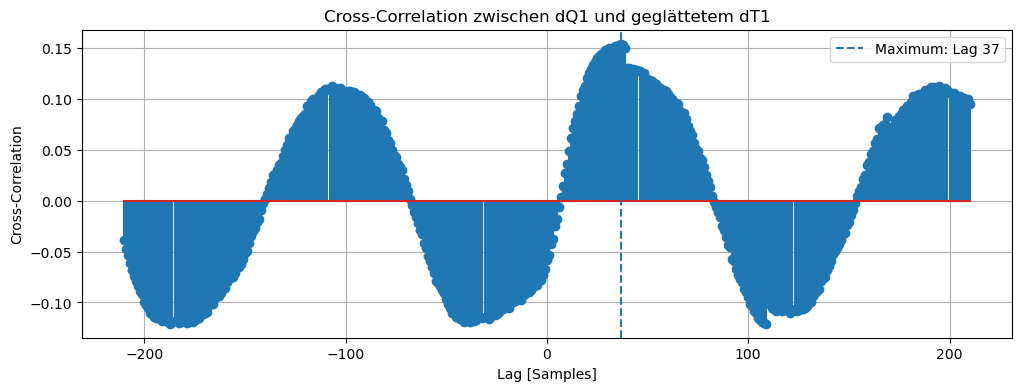

Maximum bei Lag = 37 Samples
Entspricht ca. 74.0 s


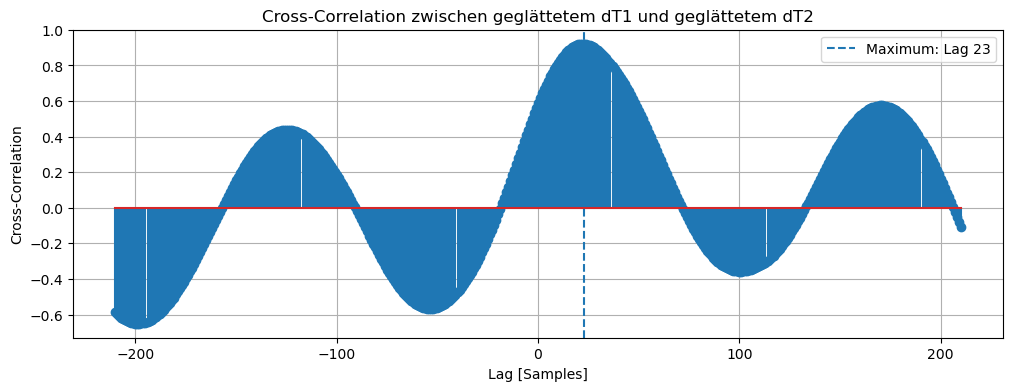

Maximum bei Lag = 23 Samples
Entspricht ca. 46.0 s


In [32]:
df["dQ1"] = df["Q1"].diff()
df["dT1"] = df["T1"].diff()
df["dT2"] = df["T2"].diff()

# kurze zentrierte Glättung der Temperaturänderungen
diff_smooth_rule = "30s"
df_ts = add_timedelta_index(df, time_col="time_s")
df_ts["dT1_smooth"] = df_ts["dT1"].rolling(
    diff_smooth_rule,
    min_periods=1,
    center=True
).mean()
df_ts["dT2_smooth"] = df_ts["dT2"].rolling(
    diff_smooth_rule,
    min_periods=1,
    center=True
).mean()

df["dT1_smooth"] = df_ts["dT1_smooth"].to_numpy()
df["dT2_smooth"] = df_ts["dT2_smooth"].to_numpy()

analysis_diff = df[["dQ1", "dT1_smooth", "dT2_smooth"]].dropna()

ccf_dq1_dt1, best_lag_dq1_dt1, best_delay_dq1_dt1_s = plot_ccf(
    signal_a=analysis_diff["dQ1"],
    signal_b=analysis_diff["dT1_smooth"],
    max_lag=max_lag_ccf,
    sample_time_s=SAMPLE_TIME_S,
    title="Cross-Correlation zwischen dQ1 und geglättetem dT1"
)

ccf_dt1_dt2, best_lag_dt1_dt2, best_delay_dt1_dt2_s = plot_ccf(
    signal_a=analysis_diff["dT1_smooth"],
    signal_b=analysis_diff["dT2_smooth"],
    max_lag=max_lag_ccf,
    sample_time_s=SAMPLE_TIME_S,
    title="Cross-Correlation zwischen geglättetem dT1 und geglättetem dT2"
)

## 15. Manuelle Verschiebung zur Kontrolle

Die geschätzten Verzögerungen werden anschaulich geprüft.

Dazu wird das Eingangssignal bzw. die erste Temperaturmessgröße um den gefundenen Lag verschoben und mit dem Zielsignal verglichen.

Diese Verschiebung ist kein Prozessmodell. Sie dient nur der Visualisierung des zeitlichen Zusammenhangs.


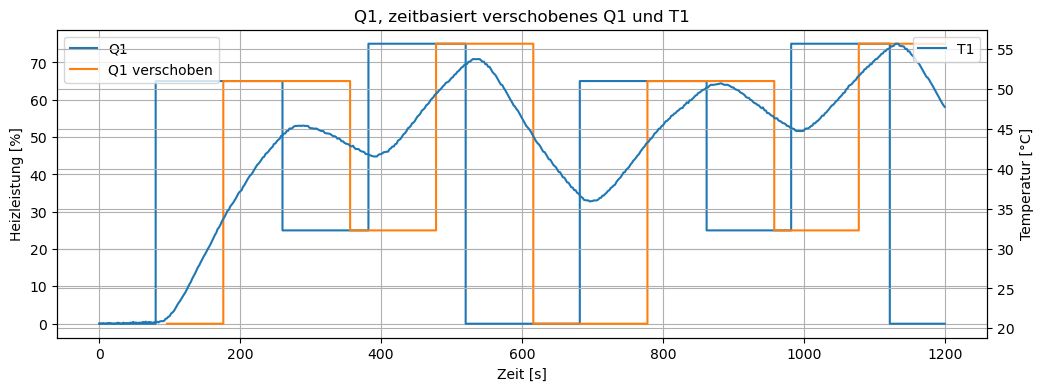

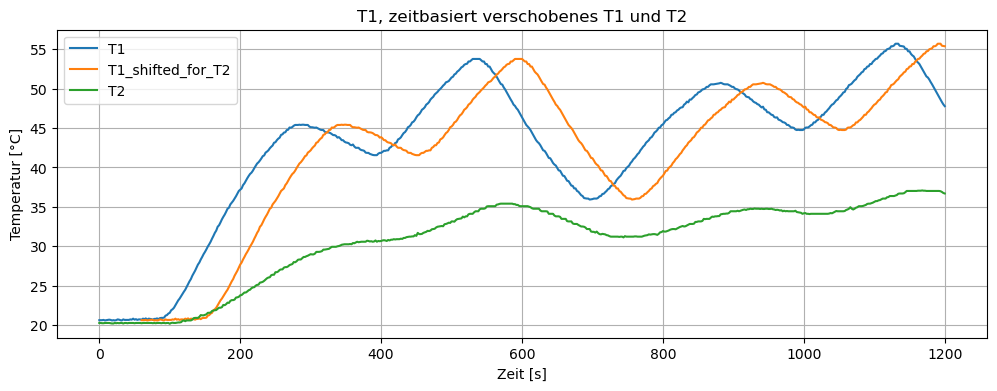

In [34]:
df["Q1_shifted_for_T1"] = time_shifted_feature(df, "Q1", delay_s=best_delay_q1_t1_s)
df["T1_shifted_for_T2"] = time_shifted_feature(df, "T1", delay_s=best_delay_t1_t2_s)

fig, ax1 = plt.subplots(figsize=(12, 4))
ax1.step(df["time_s"], df["Q1"], label="Q1", where="post")
ax1.step(df["time_s"], df["Q1_shifted_for_T1"], label="Q1 verschoben", where="post")
ax1.set_xlabel("Zeit [s]")
ax1.set_ylabel("Heizleistung [%]")
ax1.legend(loc="upper left")

ax2 = ax1.twinx()
ax2.plot(df["time_s"], df["T1"], label="T1", linestyle="-")
ax2.set_ylabel("Temperatur [°C]")
ax2.legend(loc="upper right")

plt.title("Q1, zeitbasiert verschobenes Q1 und T1")
plt.show()

ax = df.plot(x="time_s", y=["T1", "T1_shifted_for_T2", "T2"])
ax.set_title("T1, zeitbasiert verschobenes T1 und T2")
ax.set_xlabel("Zeit [s]")
ax.set_ylabel("Temperatur [°C]")
plt.show()

## 16. STL-Zerlegung von `T1`

Das Stufenprofil wird in der Standardkonfiguration über zwei Zyklen wiederholt. Dadurch kann exemplarisch eine STL-Zerlegung durchgeführt werden.

Wichtig: Bei kurzen Laborversuchen ist STL nur explorativ zu verstehen. Die wiederholte Anregung ist kein natürlicher saisonaler Prozess, sondern ein aufgeprägter Versuchszyklus.

Trotzdem ist die Darstellung didaktisch hilfreich:

- Trend: langsamer Verlauf über das gesamte Experiment
- zyklische Komponente: wiederkehrender Anteil passend zum Stufenprofil
- Residuum: nicht durch Trend und Zyklus erklärter Rest

Falls eine Messung vorzeitig abgebrochen wurde und keine zwei vollständigen Profilzyklen enthält, wird eine vorsichtige Fallback-Periode verwendet. Diese Fallback-Zerlegung ist dann nur als technische Demonstration zu interpretieren.


STL mit nominaler Profilperiode: 300 Samples


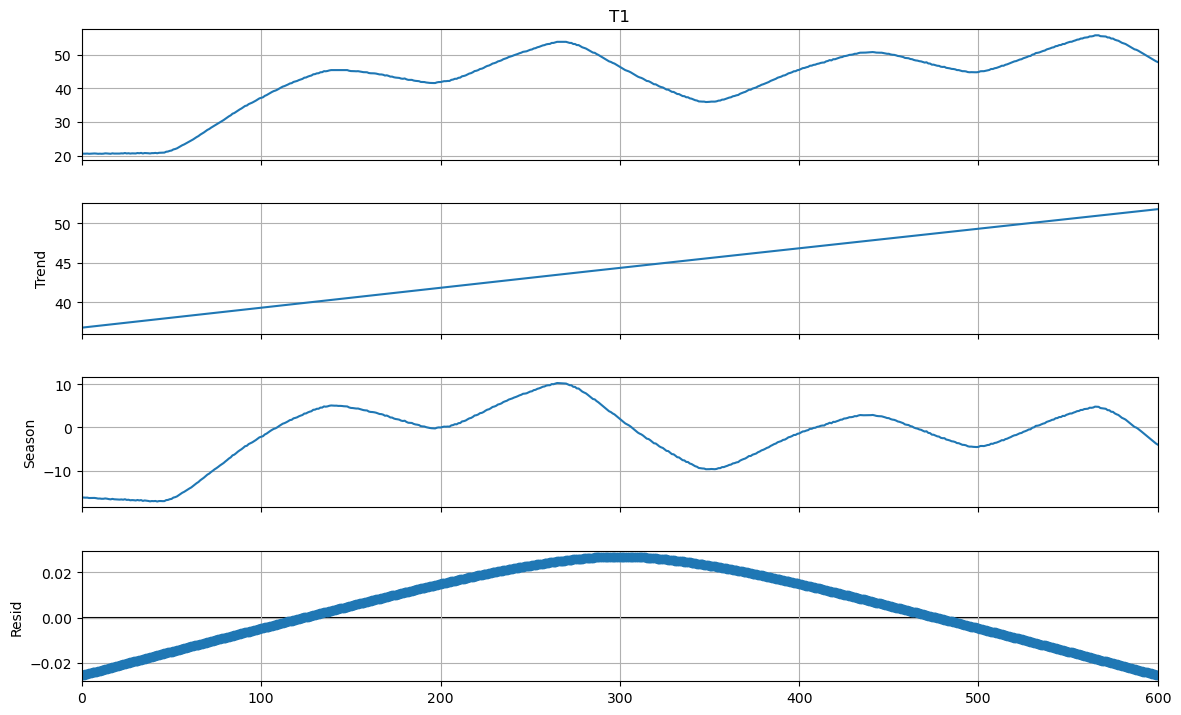

In [36]:
stl_period_steps_nominal = int(round(STL_PERIOD_S / SAMPLE_TIME_S))
min_required_nominal = 2 * stl_period_steps_nominal

if len(df) >= min_required_nominal:
    stl_period_steps = stl_period_steps_nominal
    print(f"STL mit nominaler Profilperiode: {stl_period_steps} Samples")
else:
    # Fallback: möglichst große Periode, die noch mindestens zweimal in die Daten passt
    stl_period_steps = max(20, int(len(df) // 2 - 1))
    print("Hinweis: Es liegen keine zwei vollständigen nominalen Profilzyklen vor.")
    print(f"Vorhandene Messpunkte: {len(df)}")
    print(f"Nominal benötigt: {min_required_nominal}")
    print(f"Fallback-Periode für technische Demonstration: {stl_period_steps} Samples")

if len(df) >= 2 * stl_period_steps and stl_period_steps >= 20:
    stl_result_t1 = STL(df["T1"], period=stl_period_steps, robust=True).fit()

    fig = stl_result_t1.plot()
    fig.set_size_inches(12, 8)
    plt.show()

    df["T1_stl_trend"] = stl_result_t1.trend
    df["T1_stl_seasonal"] = stl_result_t1.seasonal
    df["T1_stl_resid"] = stl_result_t1.resid
else:
    print("Für eine sinnvolle STL-Zerlegung sind zu wenige Messpunkte vorhanden.")

## 17. Zusammenfassung der Auswertung

Die folgende Tabelle fasst zentrale Kennwerte zusammen.

Bei echten Messungen können die Werte je nach Umgebung, Ausgangstemperatur, Luftbewegung und Hardware leicht variieren.


In [38]:
summary_rows = [
    {
        "Analyse": "CCF Q1 → T1",
        "Lag_samples": best_lag_q1_t1,
        "Delay_s": best_delay_q1_t1_s,
        "Interpretation": "effektive Verzögerung der Temperaturantwort",
    },
    {
        "Analyse": "CCF T1 → T2",
        "Lag_samples": best_lag_t1_t2,
        "Delay_s": best_delay_t1_t2_s,
        "Interpretation": "thermische Kopplung zwischen Messstellen",
    },
    {
        "Analyse": "CCF dQ1 → dT1",
        "Lag_samples": best_lag_dq1_dt1,
        "Delay_s": best_delay_dq1_dt1_s,
        "Interpretation": "Verzögerung der Temperaturänderung nach Stellgrößenänderung",
    },
    {
        "Analyse": "CCF dT1 → dT2",
        "Lag_samples": best_lag_dt1_dt2,
        "Delay_s": best_delay_dt1_dt2_s,
        "Interpretation": "Verzögerung der Temperaturänderung zwischen Messstellen",
    },
]

summary_df = pd.DataFrame(summary_rows)
display(summary_df)

print("Temperaturhub:")
print(f"T1: {df['T1'].min():.2f} °C bis {df['T1'].max():.2f} °C")
print(f"T2: {df['T2'].min():.2f} °C bis {df['T2'].max():.2f} °C")

,Analyse,Lag_samples,Delay_s,Interpretation
0,CCF Q1 → T1,48,96,effektive Verzögerung der Temperaturantwort
1,CCF T1 → T2,30,60,thermische Kopplung zwischen Messstellen
2,CCF dQ1 → dT1,37,74,Verzögerung der Temperaturänderung nach Stellg...
3,CCF dT1 → dT2,23,46,Verzögerung der Temperaturänderung zwischen Me...


Temperaturhub:
T1: 20.58 °C bis 55.70 °C
T2: 20.16 °C bis 37.08 °C


## 18. Übungsaufgaben

1. Führen Sie das Notebook zunächst in der Simulation aus.
2. Prüfen Sie, ob die Sprünge in `Q1` in `T1` deutlich sichtbar sind.
3. Vergleichen Sie Rohdaten und reguläres Analyse-Zeitgitter. Warum ist das reguläre Zeitraster für ACF, PACF, CCF und Lag-Features wichtig?
4. Vergleichen Sie die CCF `Q1 → T1` mit der CCF `T1 → T2`.
5. Ändern Sie `SAMPLE_TIME_S` von 2 s auf 5 s oder 10 s. Wie verändern sich ACF, PACF und CCF?
6. Prüfen Sie anschließend `ROLLING_WINDOW_S`. Warum wirkt ein 30-s-Fenster bei 10-s-Abtastung stufiger als ein 120-s-Fenster?
7. Vergleichen Sie `T1_roll_causal` und `T1_roll_centered`. Warum hat der kausale Rolling Mean einen sichtbaren Nachlauf?
8. Reduzieren Sie die Messdauer auf einen Zyklus. Was passiert mit der STL-Zerlegung?
9. Erhöhen oder senken Sie die Stufenhöhen in `heater_profile_q1`. Wie verändert sich die Erkennbarkeit der Verzögerungen?
10. Schalten Sie später optional `Q2` mit einem eigenen Profil ein. Warum wird die Interpretation von `T1 → T2` dadurch schwieriger?

Zusatzfrage:

Warum ist die CCF bei realen, trägen Prozesszeitreihen eher ein exploratives Werkzeug als ein exakter Totzeitschätzer?


## 19. Fazit

Dieses Notebook überträgt die Grundlagen der Prozesszeitreihenanalyse auf das TCLab.

Zentrale Erkenntnisse:

- Ein bewusstes Stufenprofil erzeugt auswertbare dynamische Prozessdaten.
- Temperaturzeitreihen sind stark autokorreliert.
- Cross-Correlation kann zeitliche Zusammenhänge sichtbar machen.
- Bei trägen Prozessen zeigt das CCF-Maximum oft eine effektive Signalverzögerung, nicht die reine Totzeit.
- `T1` und `T2` können als gekoppelte Messgrößen betrachtet werden.
- STL kann bei wiederholtem Versuchsprofil explorativ zur Zerlegung genutzt werden, sollte aber bei kurzen Laborversuchen vorsichtig interpretiert werden.

Damit bildet das Notebook eine Brücke von synthetischen Prozesszeitreihen zu echten bzw. simulierten TCLab-Messdaten.
